# Decision Stump (Árbol de Decisión de un Solo Nivel)

**Descripción:**

Un *decision stump* es un árbol de decisión de **profundidad 1**: consiste en un único nodo de decisión (una sola pregunta sobre un solo atributo) y dos hojas. Es, literalmente, la regla de clasificación más simple que puede expresarse como árbol: "si el atributo \\(x_j\\) supera el umbral \\(t\\), predice la clase A; si no, predice la clase B". El término fue formalizado por Iba y Langley (1992) bajo el nombre de *one-level decision trees*, y está estrechamente relacionado con las reglas **1R** de Holte (1993), quien mostró empíricamente que reglas basadas en un solo atributo alcanzan una exactitud sorprendentemente competitiva en muchos datasets reales. Por sí solo, un stump es un clasificador **débil** (*weak learner*): tiene sesgo alto y varianza baja, y rara vez es el modelo final. Su importancia práctica moderna viene de otro lado: es el aprendiz base **por excelencia del *boosting***. AdaBoost (Freund y Schapire, 1997) combina cientos de stumps —cada uno entrenado sobre una reponderación de los datos que enfatiza los errores de los anteriores— para producir un clasificador fuerte, y esa combinación de "muchos árboles de un nivel" sigue siendo la configuración clásica del algoritmo.

**Bibtex y Referencias:**

```bibtex
@inproceedings{iba1992induction,
  title={Induction of one-level decision trees},
  author={Iba, Wayne and Langley, Pat},
  booktitle={Proceedings of the Ninth International Workshop on Machine Learning},
  pages={233--240},
  year={1992},
  publisher={Morgan Kaufmann}
}

@article{holte1993very,
  title={Very simple classification rules perform well on most commonly used datasets},
  author={Holte, Robert C.},
  journal={Machine Learning},
  volume={11},
  number={1},
  pages={63--90},
  year={1993},
  publisher={Springer}
}

@article{freund1997decision,
  title={A decision-theoretic generalization of on-line learning and an application to boosting},
  author={Freund, Yoav and Schapire, Robert E.},
  journal={Journal of Computer and System Sciences},
  volume={55},
  number={1},
  pages={119--139},
  year={1997},
  publisher={Elsevier}
}
```

**Tipo de Modelo:**
- **Método de aprendizaje:** Aprendizaje supervisado — clasificación (también existe la variante de regresión: un corte y una constante por hoja)
- **Por parámetros:** Modelo de capacidad fija y mínima — a diferencia de un árbol completo, su estructura no crece con los datos: siempre es un atributo + un umbral + dos predicciones. Es el extremo de **sesgo alto / varianza baja** de la familia de árboles
- **Datos de aprendizaje:** Aprendizaje por lotes (*batch*/offline) sobre datos etiquetados
- **Resultado del entrenamiento:** Aprendizaje basado en modelo (*eager learning*) — produce una regla explícita e interpretable de una sola condición

**Alg. Entrenamiento:**
- Búsqueda **exhaustiva**: para cada atributo se evalúan todos los umbrales candidatos (puntos medios entre valores consecutivos ordenados) y se calcula la impureza resultante de la partición (entropía, Gini o error de clasificación).
- Se elige el par (atributo, umbral) que **minimiza la impureza ponderada** de las dos hojas; cada hoja predice la clase mayoritaria de su subconjunto.
- Es exactamente la primera iteración de CART/C4.5 detenida en profundidad 1 — no hay recursión, ni poda, ni criterio de parada que decidir. Complejidad \\(O(d \\cdot n \\log n)\\) para \\(d\\) atributos y \\(n\\) muestras.
- Dentro de **AdaBoost**, el mismo procedimiento se repite en cada ronda pero sobre datos **reponderados**: el stump \\(m\\) se entrena minimizando el error ponderado por los pesos \\(w_i\\), que aumentan para las muestras mal clasificadas por los stumps anteriores; la predicción final es el voto ponderado de todos los stumps.

**Supuestos y Restricciones:**
- Asume que **un solo atributo con un solo umbral** separa razonablemente las clases — la frontera de decisión es un único hiperplano perpendicular a un eje. Cualquier estructura que requiera combinar dos o más atributos (p. ej. XOR) es inaprendible para un stump aislado.
- Sesgo alto y varianza baja: casi nunca sobreajusta, pero por sí solo suele quedarse corto frente al árbol completo. Esa estabilidad es justo lo que lo hace ideal como aprendiz débil de boosting.
- Invariante a la escala de los atributos (como todo árbol de particiones) y robusto a atributos irrelevantes: simplemente los ignora al elegir el mejor corte.
- scikit-learn no tiene una clase `DecisionStump`, pero se obtiene de forma exacta con `DecisionTreeClassifier(max_depth=1)`; es además el estimador base clásico de `AdaBoostClassifier`.

# Demostración práctica: Decision Stump con scikit-learn

scikit-learn no necesita una clase especial: un stump es un `DecisionTreeClassifier(max_depth=1)`. Sobre el dataset **Breast Cancer Wisconsin** (569 tumores descritos por 30 atributos numéricos, objetivo binario maligno/benigno, incluido en scikit-learn) vamos a: (1) entrenar y evaluar un stump aislado, (2) visualizar la regla única que aprende, (3) compararlo contra un árbol completo, y (4) mostrar su rol estelar como aprendiz débil dentro de **AdaBoost**.

In [10]:
# En Colab scikit-learn, numpy, pandas y matplotlib ya vienen instalados.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

np.random.seed(42)  # reproducibilidad

## 1. Cargar y dividir los datos

Usamos **Breast Cancer Wisconsin**: 569 muestras, 30 atributos numéricos continuos (radio medio, textura, perímetro, concavidad, etc., medidos sobre imágenes de núcleos celulares) y objetivo binario (`malignant`/`benign`). Es un buen escenario para un stump porque varios atributos individuales (como `worst perimeter` o `worst concave points`) separan las clases bastante bien por sí solos — exactamente el supuesto que un stump necesita. Reservamos el 20 % para prueba, estratificando para conservar la proporción de clases.

In [11]:
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
feature_names = list(cancer.feature_names)
class_names = list(cancer.target_names)  # ['malignant', 'benign']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Entrenamiento: {X_train.shape[0]} muestras | Prueba: {X_test.shape[0]} muestras")
print(f"Atributos: {X.shape[1]} | Clases: {class_names}")

Entrenamiento: 455 muestras | Prueba: 114 muestras
Atributos: 30 | Clases: [np.str_('malignant'), np.str_('benign')]


## 2. Entrenar un decision stump

`max_depth=1` es lo único que distingue a un stump de un árbol normal en scikit-learn. Con 30 atributos disponibles, el entrenamiento consiste en probar todos los umbrales de cada atributo y quedarse con el corte que más reduce la impureza (usamos entropía; con Gini el resultado es prácticamente idéntico aquí).

In [12]:
stump = DecisionTreeClassifier(max_depth=1, criterion="entropy", random_state=42)
stump.fit(X_train, y_train)

y_pred_stump = stump.predict(X_test)
acc_stump = accuracy_score(y_test, y_pred_stump)

atributo = feature_names[stump.tree_.feature[0]]
umbral = stump.tree_.threshold[0]
print(f"Regla aprendida: si '{atributo}' <= {umbral:.3f} -> una clase; si no -> la otra")
print(f"Exactitud en prueba: {acc_stump:.3f}")

Regla aprendida: si 'worst radius' <= 16.795 -> una clase; si no -> la otra
Exactitud en prueba: 0.921


## 3. Visualizar el stump

Todo el modelo cabe en un dibujo de 3 nodos. Además, graficamos la distribución del atributo elegido por clase, con el umbral marcado, para ver *por qué* el algoritmo eligió justamente ese corte: es el punto que mejor separa malignos de benignos usando una sola variable.

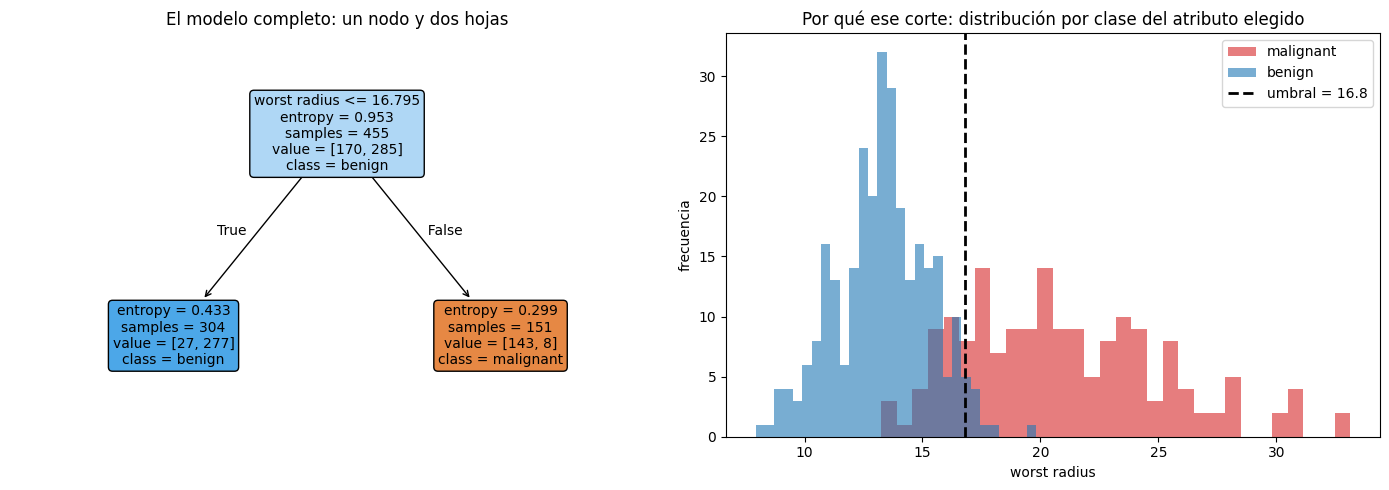

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_tree(
    stump,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=axes[0],
)
axes[0].set_title("El modelo completo: un nodo y dos hojas")

idx = stump.tree_.feature[0]
for clase, color in [(0, "tab:red"), (1, "tab:blue")]:
    axes[1].hist(
        X_train[y_train == clase, idx],
        bins=30, alpha=0.6, color=color, label=class_names[clase],
    )
axes[1].axvline(umbral, color="k", linestyle="--", linewidth=2, label=f"umbral = {umbral:.1f}")
axes[1].set_xlabel(atributo)
axes[1].set_ylabel("frecuencia")
axes[1].set_title("Por qué ese corte: distribución por clase del atributo elegido")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Matriz de confusión y reporte de clasificación

Aunque el stump usa un solo atributo de los 30 disponibles, su exactitud ya supera con claridad al azar (~63 % sería predecir siempre la clase mayoritaria). Esto ilustra el hallazgo de Holte (1993): reglas de un solo atributo rinden sorprendentemente bien en datasets reales.

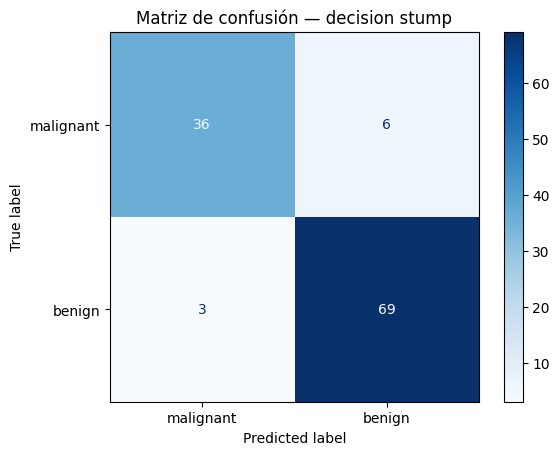

              precision    recall  f1-score   support

   malignant       0.92      0.86      0.89        42
      benign       0.92      0.96      0.94        72

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



In [14]:
cm = confusion_matrix(y_test, y_pred_stump)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues")
plt.title("Matriz de confusión — decision stump")
plt.show()

print(classification_report(y_test, y_pred_stump, target_names=class_names))

## 5. Stump vs. árbol completo vs. AdaBoost (la parte que más importa)

Aquí está la lección central del decision stump. Comparamos tres modelos:

1. **Stump aislado** — el aprendiz débil.
2. **Árbol completo sin restricción** — baja el sesgo pero sube la varianza (memoriza el conjunto de entrenamiento).
3. **AdaBoost con 200 stumps** — cada stump se entrena sobre los datos reponderados para corregir los errores de los anteriores; el resultado combina la estabilidad del stump con la capacidad de un modelo complejo.

El punto conceptual: *boosting* convierte a un clasificador apenas mejor que el azar en uno de los mejores clasificadores disponibles, y el stump es el aprendiz débil canónico para eso.

In [15]:
arbol_completo = DecisionTreeClassifier(criterion="entropy", random_state=42)
arbol_completo.fit(X_train, y_train)

adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # el aprendiz débil: un stump
    n_estimators=200,
    random_state=42,
)
adaboost.fit(X_train, y_train)

comparacion = pd.DataFrame({
    "modelo": [
        "Decision stump (max_depth=1)",
        "Árbol completo (sin límite)",
        "AdaBoost (200 stumps)",
    ],
    "exactitud (test)": [
        acc_stump,
        accuracy_score(y_test, arbol_completo.predict(X_test)),
        accuracy_score(y_test, adaboost.predict(X_test)),
    ],
    "exactitud (train)": [
        accuracy_score(y_train, stump.predict(X_train)),
        accuracy_score(y_train, arbol_completo.predict(X_train)),
        accuracy_score(y_train, adaboost.predict(X_train)),
    ],
})
comparacion

,modelo,exactitud (test),exactitud (train)
0,Decision stump (max_depth=1),0.921053,0.923077
1,Árbol completo (sin límite),0.912281,1.000000
2,AdaBoost (200 stumps),0.964912,1.000000


## 6. Cómo mejora AdaBoost al agregar stumps

`staged_predict` permite evaluar el ensamble tras cada stump añadido. La curva muestra el error de prueba cayendo a medida que se suman stumps: cada uno aporta la "vista" de un atributo/umbral distinto sobre los datos reponderados. La línea horizontal marca el error del stump aislado — la distancia entre ambas es exactamente lo que aporta el boosting.

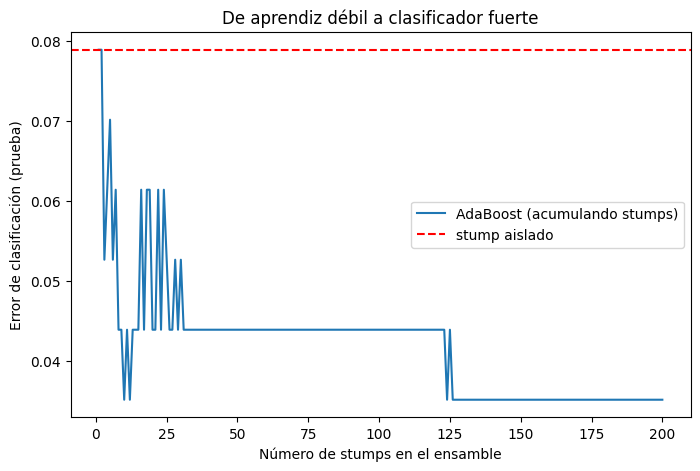

In [16]:
errores_test = [
    1 - accuracy_score(y_test, pred)
    for pred in adaboost.staged_predict(X_test)
]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(errores_test) + 1), errores_test, label="AdaBoost (acumulando stumps)")
plt.axhline(1 - acc_stump, color="r", linestyle="--", label="stump aislado")
plt.xlabel("Número de stumps en el ensamble")
plt.ylabel("Error de clasificación (prueba)")
plt.title("De aprendiz débil a clasificador fuerte")
plt.legend()
plt.show()

## 7. Qué atributos usan los stumps del ensamble

Cada stump del ensamble elige (sobre sus datos reponderados) el atributo con mejor corte en esa ronda. Contar qué atributos aparecen más entre los 200 stumps da una lectura de importancia de variables distinta a la del stump aislado: el ensamble reparte su atención entre varios atributos complementarios, mientras que el stump solo pudo usar uno.

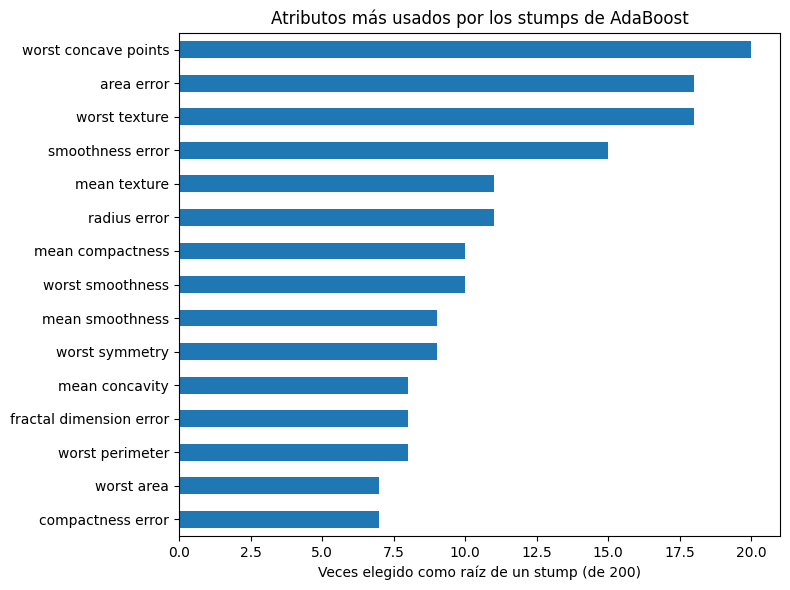

In [17]:
atributos_usados = pd.Series(
    [feature_names[est.tree_.feature[0]] for est in adaboost.estimators_]
).value_counts().sort_values()

plt.figure(figsize=(8, 6))
atributos_usados.tail(15).plot(kind="barh")
plt.xlabel("Veces elegido como raíz de un stump (de 200)")
plt.title("Atributos más usados por los stumps de AdaBoost")
plt.tight_layout()
plt.show()

## 8. La limitación estructural: XOR

Para cerrar, un contraejemplo sintético que ningún stump puede aprender: el problema XOR, donde la clase depende de la **combinación** de dos atributos y ningún corte sobre un solo eje separa nada. El stump se queda en ~50 % (azar) *incluso sobre sus propios datos de entrenamiento* — es una limitación de representación, no de generalización. Un detalle instructivo: como en XOR la primera partición no aporta ganancia para ningún corte, el árbol voraz elige la raíz casi al azar, y por eso incluso un árbol de profundidad 2 (que en teoría puede representar XOR con sus 4 hojas) suele fallar; hace falta dejar crecer el árbol para que aísle las cuatro regiones. Esto delimita con precisión el supuesto del modelo: el stump sirve cuando un atributo individual lleva señal, y falla cuando la señal solo emerge de interacciones.

Stump (profundidad 1) en XOR:      0.532  <- apenas azar: no puede ni ajustar los datos
Árbol sin límite de profundidad:   1.000  <- sí puede representar la interacción


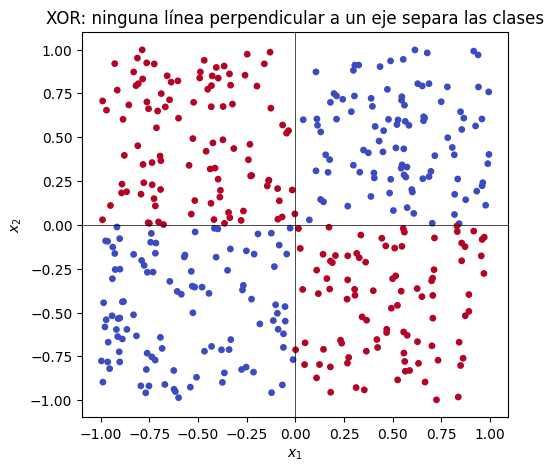

In [18]:
rng = np.random.default_rng(42)
X_xor = rng.uniform(-1, 1, size=(400, 2))
y_xor = ((X_xor[:, 0] > 0) ^ (X_xor[:, 1] > 0)).astype(int)

stump_xor = DecisionTreeClassifier(max_depth=1, random_state=42).fit(X_xor, y_xor)
arbol_xor = DecisionTreeClassifier(random_state=42).fit(X_xor, y_xor)  # sin límite de profundidad

print(f"Stump (profundidad 1) en XOR:      {stump_xor.score(X_xor, y_xor):.3f}  <- apenas azar: no puede ni ajustar los datos")
print(f"Árbol sin límite de profundidad:   {arbol_xor.score(X_xor, y_xor):.3f}  <- sí puede representar la interacción")

plt.figure(figsize=(5.5, 5))
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap="coolwarm", s=15)
plt.axhline(0, color="k", linewidth=0.5)
plt.axvline(0, color="k", linewidth=0.5)
plt.title("XOR: ninguna línea perpendicular a un eje separa las clases")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

## 9. Conclusiones

- Un decision stump es un árbol de decisión detenido en profundidad 1: **un atributo, un umbral, dos hojas**. Se obtiene en scikit-learn con `DecisionTreeClassifier(max_depth=1)`.
- Aislado, es un clasificador débil pero honesto: en datasets donde algún atributo individual lleva mucha señal (como Breast Cancer) supera con claridad al azar, confirmando el hallazgo de Holte (1993).
- Su valor real es como **aprendiz débil de AdaBoost**: 200 stumps reponderados alcanzan una exactitud comparable o superior a la de un árbol completo, con mucha menos varianza.
- Su límite es estructural: no puede capturar interacciones entre atributos (XOR), porque su frontera de decisión es un único corte perpendicular a un eje.